# 06 — O Que Mais Influencia o Peso

Um modelo que só acerta o número não me diz muita coisa. Eu quis entender **o que ele usa
pra prever** quais variáveis pesam mais. Usei o permutation importance, que embaralha
cada variável e mede o quanto a previsão piora: se piora muito, aquela variável é
importante.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100; plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.3

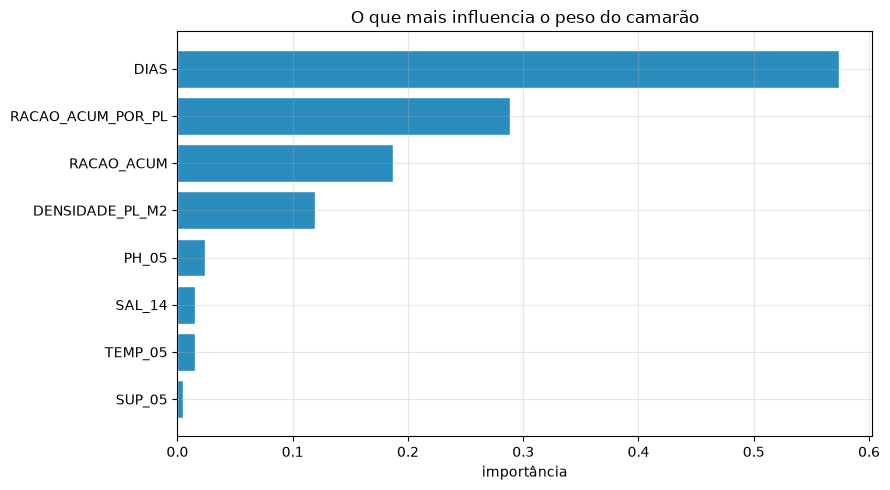

,feature,imp
0,DIAS,0.574
2,RACAO_ACUM_POR_PL,0.289
1,RACAO_ACUM,0.187
3,DENSIDADE_PL_M2,0.119
6,PH_05,0.024
7,SAL_14,0.015
5,TEMP_05,0.015
4,SUP_05,0.005


In [2]:
from src.peso import construir_dataset_peso, FEATURES_PESO
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor
df = construir_dataset_peso()
feats=[f for f in FEATURES_PESO if f in df.columns]
X = df[feats].fillna(df[feats].median()); y = df["PESO"]
rf = RandomForestRegressor(n_estimators=300,max_depth=8,min_samples_leaf=3,random_state=42).fit(X,y)
r = permutation_importance(rf, X, y, n_repeats=10, random_state=42, scoring="r2")
imp = pd.DataFrame({"feature":feats,"imp":r.importances_mean}).sort_values("imp")
plt.figure(figsize=(9,5))
plt.barh(imp["feature"], imp["imp"], color="#2b8cbe", edgecolor="white")
plt.xlabel("importância")
plt.title("O que mais influencia o peso do camarão")
plt.tight_layout(); plt.show()
imp.sort_values("imp",ascending=False).round(3)

## O que eu concluí

O **dia de cultivo** é disparado a variável mais importante, seguido da **ração acumulada
por animal**. Isso bate exatamente com o que o estudo da Indonésia encontrou, lá o "day
of culture" sozinho respondeu por mais da metade da importância. Faz todo sentido
biológico: o que mais determina o tamanho do camarão é há quanto tempo ele cresce e quanto
ele comeu no total. As variáveis de ambiente (oxigênio, pH, temperatura) têm peso bem
menor.

**Próximo (07):** conclusões.